In [92]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm

from visionsim.emulate.aspc.camera import Camera
from visionsim.emulate.aspc.utils import tof2depth

In [93]:
def forward_pass_ewh_diff(
    histogrammer,
    transients,
    ambient_offsets,
    irf_tensor,
):
    assert histogrammer.dead_time_s == 0, "Current differentiable EWH does not support non-zero dead time"

    arrival_rates = histogrammer.calculate_arrival_rates(irf_tensor, transients, ambient_offsets, histogrammer.n_bins)
    ewh_list = histogrammer.simulate_ewh_diff(
        arrival_rates,
        histogrammer.n_pulses,
        histogrammer.n_bins,
        histogrammer.free_running,
        histogrammer.dead_time_s,
    )

    return ewh_list

In [94]:
def rmse_loss(pred, gt):
    rmse = torch.mean(torch.mean((pred - gt) ** 2, axis=-1) ** 0.5)
    return rmse


def KL_divergence_loss(pred_hist, target_hist):
    p = target_hist / (target_hist.sum(dim=-1, keepdim=True) + 1e-10)
    q = pred_hist / (pred_hist.sum(dim=-1, keepdim=True) + 1e-10)
    # p = target_hist
    # q = pred_hist
    return F.kl_div(q.log(), p, reduction="batchmean")
    # return F.kl_div(F.log_softmax(q, dim=-1), F.softmax(p, dim=-1), reduction="batchmean")


def wasserstein_loss(pred_hist, target_hist):
    p = target_hist / (target_hist.sum(dim=-1, keepdim=True) + 1e-10)
    q = pred_hist / (pred_hist.sum(dim=-1, keepdim=True) + 1e-10)
    # p = target_hist
    # q = pred_hist
    cdf_p = torch.cumsum(p, dim=-1)
    cdf_q = torch.cumsum(q, dim=-1)
    return torch.mean(torch.square(cdf_p - cdf_q))
    # return torch.mean(torch.abs(cdf_p - cdf_q))

In [95]:
data_dir = Path("../../../../examples/renders/scene1/")
config_path = "config_diff_ewh.yaml"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
requires_grad = False
seed = 0
random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

In [96]:
camera = Camera(data_dir, config_path, device, requires_grad)
bin_width = 2 * tof2depth(1 / camera.active_source.frequency) / camera.histogrammer.n_bins
_, irf = camera.active_source.get_kernel(bin_width)
irf_tensor_gt = torch.tensor(irf, dtype=torch.float32, device=device)
transients, ambient_offsets = camera.get_transients()

depth_img min 0.9444128
depth_img max 3.25


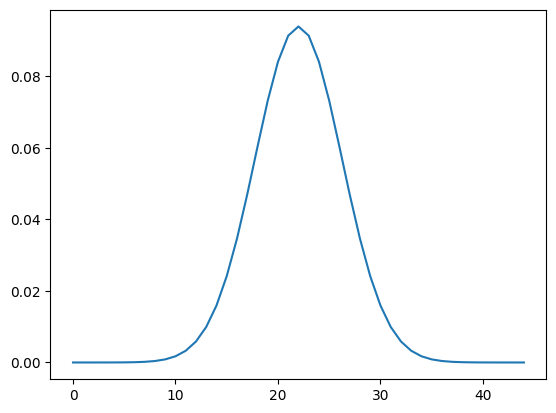

In [97]:
plt.plot(irf_tensor_gt.detach().cpu().numpy().squeeze(), label="kernel")
plt.show()

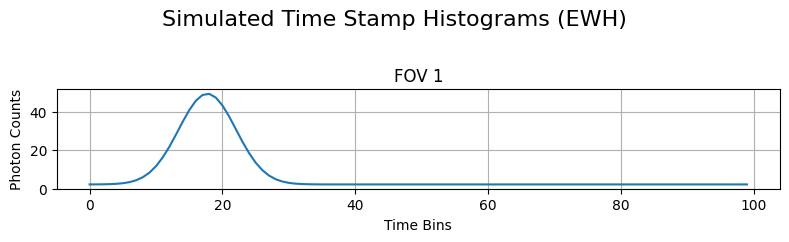

In [98]:
# ewh_list_gt = camera.get_ewh()
transients_gt, ambient_offsets_gt = camera.get_transients()
ewh_list_gt = forward_pass_ewh_diff(
    camera.histogrammer,
    transients_gt,
    ambient_offsets_gt,
    irf_tensor_gt,
)
camera.plot_ewh(1, ewh_list_gt)
if isinstance(ewh_list_gt, torch.Tensor):
    ewh_list_measurement = ewh_list_gt.to(device=device, dtype=torch.float32)
else:
    ewh_list_measurement = torch.stack(ewh_list_gt).to(device=device, dtype=torch.float32)

In [99]:
# irf_init = [0.0]*51

# irf_tensor_estim = nn.Parameter(
#     torch.tensor(irf_init, device=irf_tensor_gt.device, dtype=irf_tensor_gt.dtype), requires_grad=True
# )
irf_tensor_estim = nn.Parameter(torch.ones_like(irf_tensor_gt))

optimizer = optim.Adam([irf_tensor_estim], lr=0.05)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.9)
total_epochs = 500
loss_history = []

  0%|          | 0/500 [00:00<?, ?it/s]

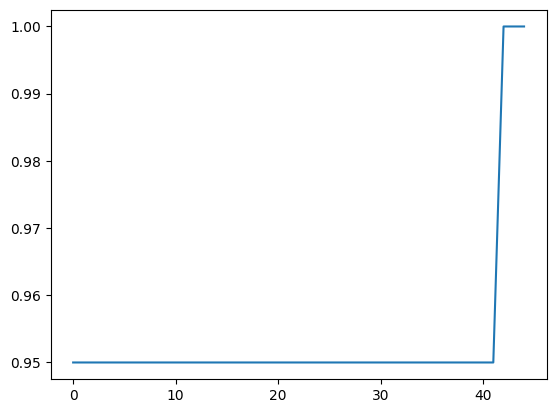

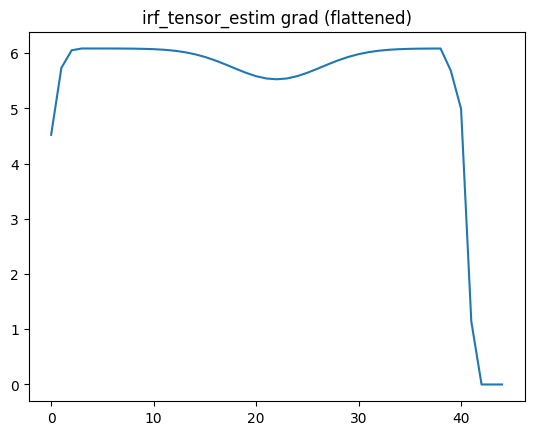

  1%|▏         | 7/500 [00:00<00:21, 23.45it/s]

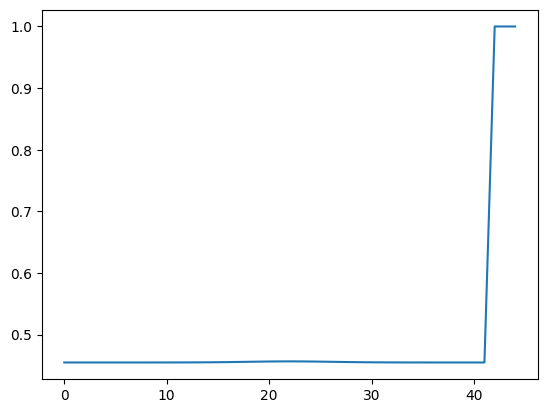

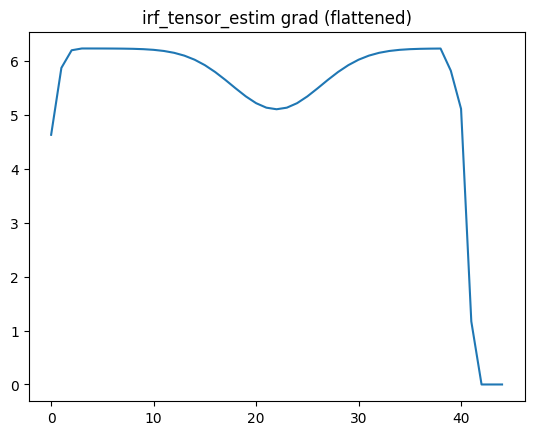

  3%|▎         | 17/500 [00:00<00:19, 24.75it/s]

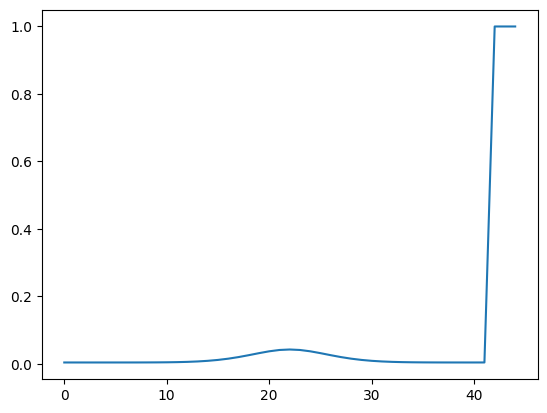

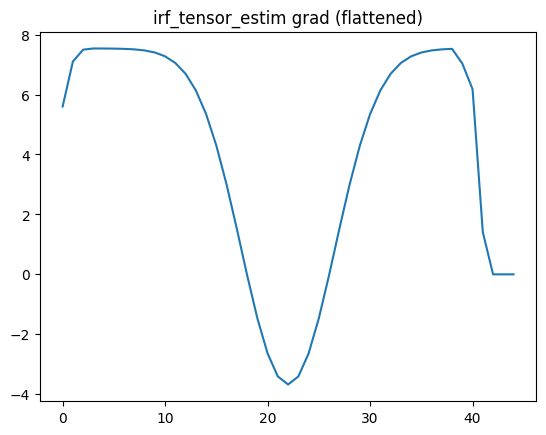

  5%|▌         | 26/500 [00:01<00:19, 24.23it/s]

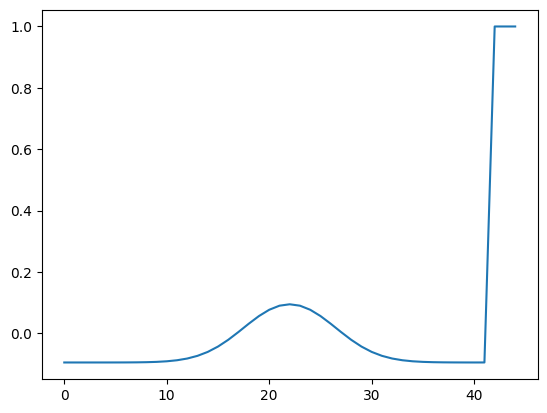

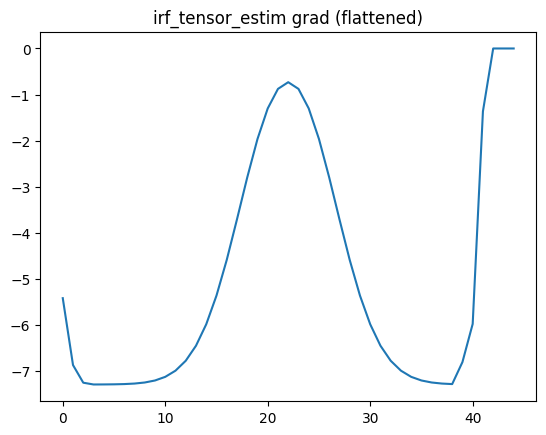

  8%|▊         | 38/500 [00:01<00:17, 25.92it/s]

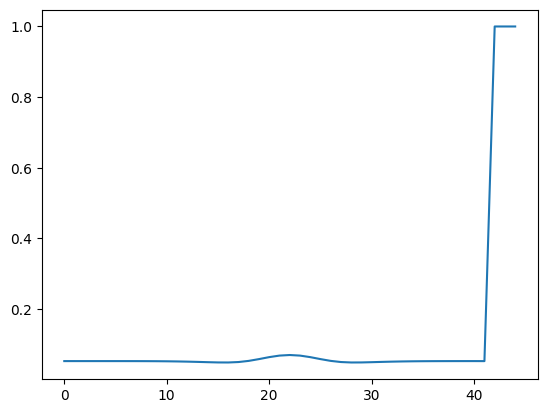

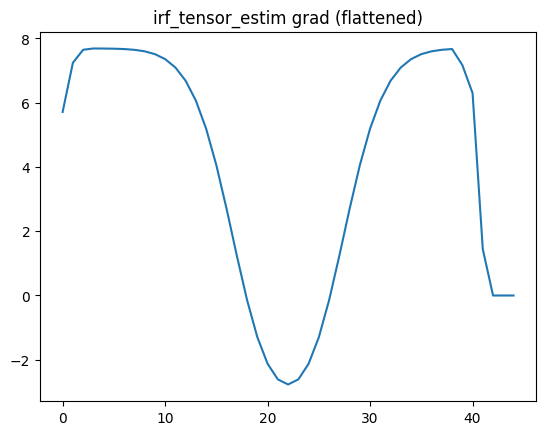

 10%|▉         | 49/500 [00:02<00:16, 27.80it/s]

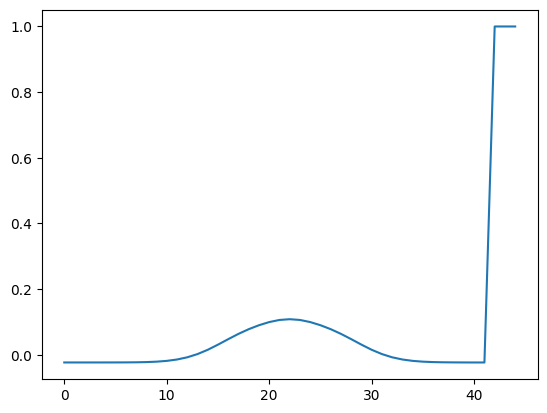

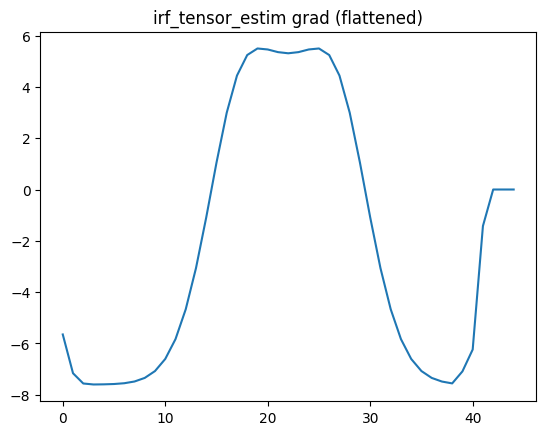

 11%|█         | 54/500 [00:02<00:20, 21.51it/s]

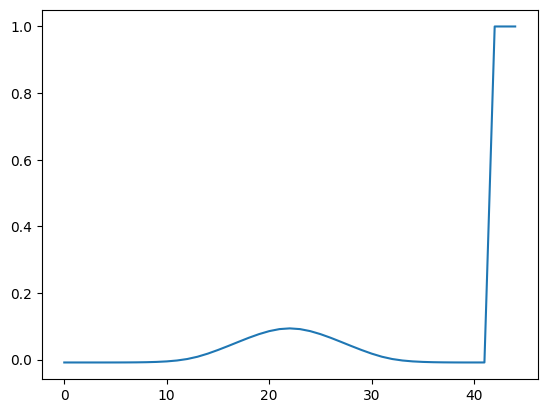

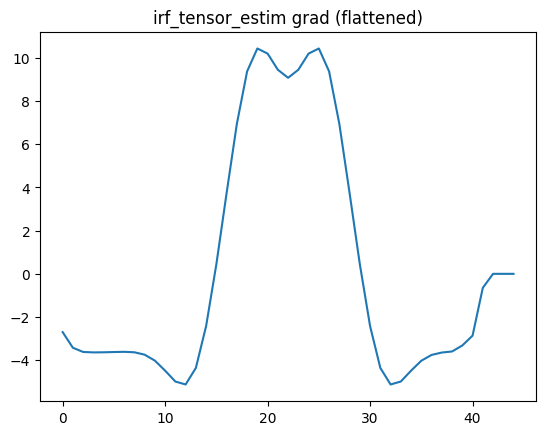

 14%|█▎        | 68/500 [00:03<00:16, 26.81it/s]

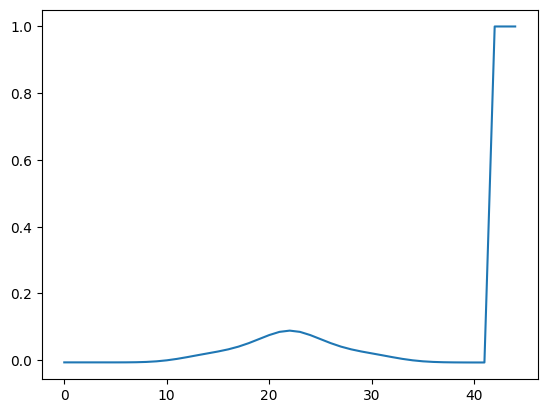

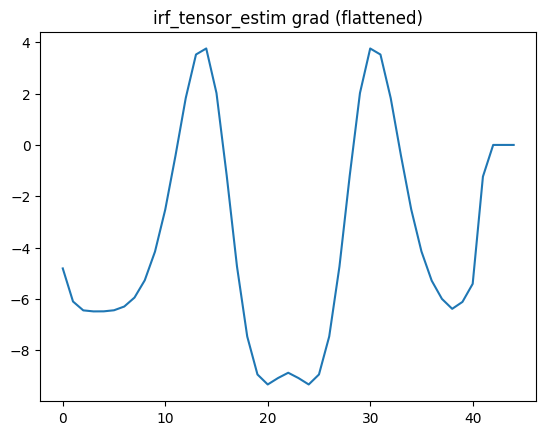

 16%|█▌        | 79/500 [00:03<00:15, 26.84it/s]

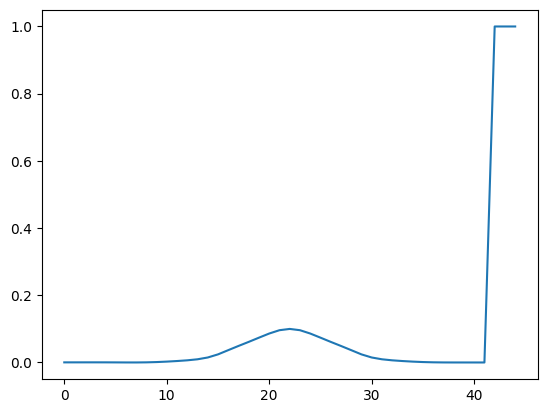

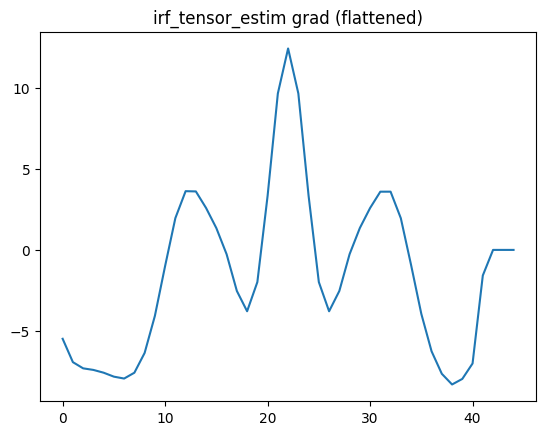

 17%|█▋        | 84/500 [00:03<00:19, 21.37it/s]

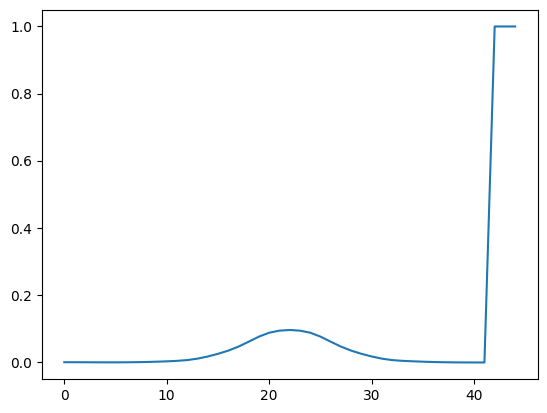

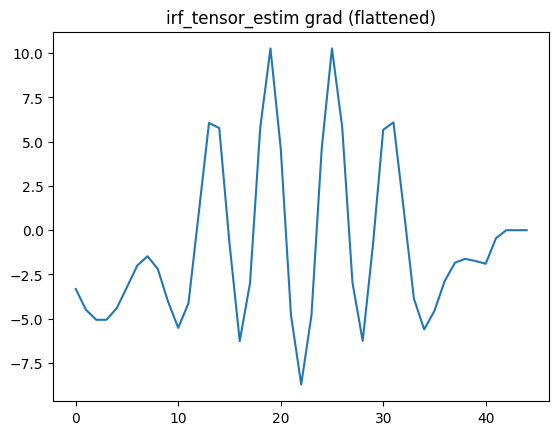

100%|██████████| 500/500 [00:11<00:00, 42.67it/s]


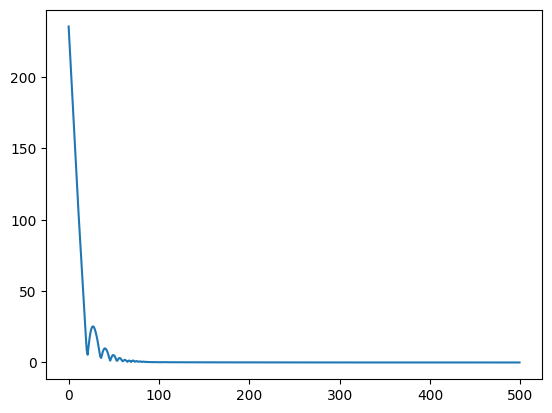

In [100]:
for epoch in tqdm(range(total_epochs)):
    optimizer.zero_grad()

    transients_pred, ambient_offsets_pred = camera.get_transients()
    ewh_list_pred = forward_pass_ewh_diff(
        camera.histogrammer,
        transients_pred,
        ambient_offsets_pred,
        irf_tensor_estim,
    )
    irf_tensor_estim.retain_grad()

    total_loss = torch.nn.functional.mse_loss(ewh_list_pred, ewh_list_measurement)
    total_loss = rmse_loss(ewh_list_pred, ewh_list_measurement)
    loss_history.append(total_loss.detach().cpu().item())
    total_loss.backward()
    optimizer.step()
    scheduler.step()

    if epoch < 100 and epoch % 10 == 0:
        plt.plot(irf_tensor_estim.detach().cpu().numpy().squeeze())
        plt.show()
        if irf_tensor_estim.grad is None:
            print("irf_tensor_estim.grad is None")
        else:
            plt.plot(irf_tensor_estim.grad.detach().cpu().numpy().reshape(-1))
            plt.title("irf_tensor_estim grad (flattened)")
            plt.show()

plt.plot(loss_history)

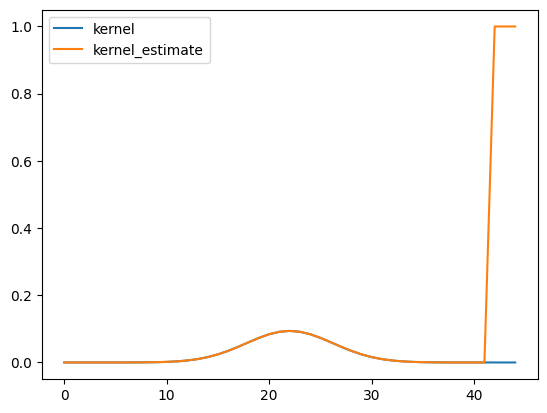

In [101]:
plt.plot(irf_tensor_gt.detach().cpu().numpy().squeeze(), label="kernel")
plt.plot(irf_tensor_estim.detach().cpu().numpy().squeeze(), label="kernel_estimate")
plt.legend()
plt.show()